[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_07/SFM_ch7_seminar/SFM_ch7_seminar.ipynb)

# Statistics of Financial Markets — Seminar 7: Efficient markets, random walk and variance-ratio tests

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 7: the slides "What You Need for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with inference and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> Quantlet `SFM_ch7_seminar`: student version of the Seminar 7 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_7'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- Returns and log prices; sample ACF, robust variance of the ACF, Box–Pierce, Ljung–Box and robust portmanteau statistics; the runs test; ADF, Phillips–Perron and KPSS; Lo–MacKinlay VR with $Z$ and $Z^*$, Chow–Denning, the automatic VR test with wild bootstrap.
- Helpers for Part A: VR from autocorrelations, the square-root-of-time rule, portmanteau statistics from given autocorrelations, the runs test from a string of signs, Dickey–Fuller and KPSS decisions.

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.adfvalues import mackinnoncrit, mackinnonp
EXTRA_SERIES = {'bvsp': ('BVSP.INDX', 'Bovespa', 'Equity', 'close', '2000-01-01'), 'nifty': ('NSEI.INDX', 'Nifty 50', 'Equity', 'close', '2000-01-01'), 'bist': ('XU100.INDX', 'BIST 100', 'Equity', 'close', '2000-01-01'), 'ssec': ('SSEC.INDX', 'Shanghai Composite', 'Equity', 'close', '2000-01-01'), 'kospi': ('KS11.INDX', 'KOSPI', 'Equity', 'close', '2000-01-01'), 'ipc': ('MXX.INDX', 'IPC Mexico', 'Equity', 'close', '2000-01-01')}
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'eth': 'Ethereum', 'stoxx50': 'Euro Stoxx 50', 'nikkei': 'Nikkei 225', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom', 'brd': 'BRD', 'tgn': 'Transgaz', 'wig20': 'WIG20', 'bux': 'BUX', 'px': 'PX', 'bvsp': 'Bovespa', 'nifty': 'Nifty 50', 'bist': 'BIST 100', 'ssec': 'Shanghai Composite', 'kospi': 'KOSPI', 'ipc': 'IPC Mexico'}
START = {'sp500': '1990-01-01', 'dax': '1990-01-01', 'bet': '1997-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01', 'brd': '2010-01-01', 'tgn': '2010-01-01'}
ASSETS = ['sp500', 'dax', 'bet', 'btc']
STOCKS = ['tlv', 'snp', 'brd', 'tgn']
DEVELOPED = ['sp500', 'dax', 'stoxx50', 'nikkei']
EMERGING = ['bet', 'wig20', 'bux', 'px', 'bist', 'bvsp', 'ipc', 'nifty', 'kospi', 'ssec']
CRYPTO = ['btc', 'eth']
MARKETS_START = '2016-09-19'
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'snp': '#2E7D32', 'brd': '#8E44AD', 'tlv': '#E67E22', 'tgn': '#DC3545'}
QS = (2, 5, 10, 20)
LB_LAGS = 10
WINDOW = 500
STEP = 21
SEED = 2026
B_BOOT = 500
FTSE_UPGRADE = '2020-09-21'
SUBPERIODS = {'bet': [('1997-01-01', '2006-12-31'), ('2007-01-01', '2016-12-31'), ('2017-01-01', None)], 'sp500': [('1990-01-01', '2001-12-31'), ('2002-01-01', '2013-12-31'), ('2014-01-01', None)], 'btc': [('2014-01-01', '2017-12-31'), ('2018-01-01', '2021-12-31'), ('2022-01-01', None)]}
DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
ACF_CASES = [('AR(1), alpha = 0.9', (0.9,), ()), ('AR(1), alpha = -0.9', (-0.9,), ()), ('AR(2), alpha1 = 0.5, alpha2 = 0.4', (0.5, 0.4), ()), ('MA(1), beta = 0.5', (), (0.5,)), ('MA(1), beta = -0.5', (), (-0.5,)), ('MA(2), beta1 = 0.5, beta2 = 0.4', (), (0.5, 0.4))]


def returns(k, start=None):
    """Daily log returns in % on the series' own calendar (from `start`, else the default start of the series);
    known data errors removed."""
    if k in EXTRA_SERIES:
        SERIES.setdefault(k, EXTRA_SERIES[k])
    r = log_returns(k, start or START.get(k))
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def log_price(k, start=None):
    """Natural logarithm of the closing price (adjusted close for stocks)."""
    if k in EXTRA_SERIES:
        SERIES.setdefault(k, EXTRA_SERIES[k])
    p = np.log(load_close(k, start or START.get(k)))
    if k in BAD_DAYS:            # the same two days as in returns(): the late adjustment cancels out
        p = p.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return p


def acf(x, nlags):
    """Sample autocorrelations rho_hat(1..nlags) = sum (x_t - m)(x_{t-k} - m) / sum (x_t - m)^2."""
    e = np.asarray(x, float) - np.mean(x)
    s = np.sum(e ** 2)
    return np.array([np.sum(e[k:] * e[:-k]) / s for k in range(1, nlags + 1)])


def acf_fft(x, nlags=None):
    """All sample autocorrelations rho_hat(1..nlags) by the fast Fourier transform (used by the automatic VR test)."""
    e = np.asarray(x, float) - np.mean(x)
    n = len(e)
    f = np.fft.rfft(e, 2 * n)
    c = np.fft.irfft(f * np.conj(f))[:n]
    return (c / c[0])[1:(nlags or n - 1) + 1]


def robust_var_acf(x, nlags):
    """delta_hat(k) / T: the variance of rho_hat(k) that allows for conditional heteroskedasticity, with
    delta_hat(k) = T sum e_t^2 e_{t-k}^2 / (sum e_t^2)^2 (Lo and MacKinlay, 1988); under i.i.d. returns it is 1/T."""
    e = np.asarray(x, float) - np.mean(x)
    s2 = np.sum(e ** 2) ** 2
    return np.array([np.sum(e[k:] ** 2 * e[:-k] ** 2) / s2 for k in range(1, nlags + 1)])


def portmanteau(x, m=LB_LAGS):
    """Box-Pierce Q = T sum rho^2, Ljung-Box Q = T(T+2) sum rho^2/(T-k) and the robust Q~ = sum rho^2/var_rob(k),
    each against chi-square(m)."""
    x = np.asarray(x, float)
    T = len(x)
    rho = acf(x, m)
    vr = robust_var_acf(x, m)
    k = np.arange(1, m + 1)
    bp = T * np.sum(rho ** 2)
    lb = T * (T + 2) * np.sum(rho ** 2 / (T - k))
    rob = np.sum(rho ** 2 / vr)
    p = lambda q: float(stats.chi2.sf(q, m))
    return {'T': T, 'm': m, 'rho1': float(rho[0]), 'bp': float(bp), 'p_bp': p(bp), 'lb': float(lb), 'p_lb': p(lb),
            'rob': float(rob), 'p_rob': p(rob), 'crit': float(stats.chi2.ppf(0.95, m))}


def runs_test(x):
    """Runs test (Wald and Wolfowitz, 1940) on the signs of the returns (zero returns dropped): number of runs R,
    E[R] = 2 n1 n2 / n + 1, Var[R] = 2 n1 n2 (2 n1 n2 - n) / (n^2 (n - 1)), z = (R - E[R]) / sd(R)."""
    s = np.sign(np.asarray(x, float))
    s = s[s != 0]
    n1, n2 = int(np.sum(s > 0)), int(np.sum(s < 0))
    n = n1 + n2
    runs = int(1 + np.sum(s[1:] != s[:-1]))
    mean = 2 * n1 * n2 / n + 1
    var = 2 * n1 * n2 * (2 * n1 * n2 - n) / (n ** 2 * (n - 1))
    z = (runs - mean) / np.sqrt(var)
    return {'n1': n1, 'n2': n2, 'runs': runs, 'mean': mean, 'sd': float(np.sqrt(var)), 'z': float(z),
            'p': float(2 * stats.norm.sf(abs(z)))}


def adf_test(x, regression='c'):
    """Augmented Dickey-Fuller test (Said and Dickey, 1984): lag order by AIC, at most 12 (T/100)^(1/4);
    p-values and critical values of MacKinnon (1996). H0: unit root."""
    stat, p, lags, nobs, crit, _ = adfuller(np.asarray(x, float), regression=regression, autolag='AIC')
    return {'stat': float(stat), 'p': float(p), 'lags': int(lags), 'nobs': int(nobs), 'crit5': float(crit['5%'])}


def pp_test(x, regression='c'):
    """Phillips-Perron (1988) Z_t test: Dickey-Fuller regression without lags, t-statistic corrected with a
    Newey-West long-run variance (Bartlett weights, l = 12 (T/100)^(1/4) rounded up). H0: unit root."""
    y = np.asarray(x, float)
    dy, ylag = y[1:], y[:-1]
    T = len(dy)
    X = [np.ones(T), ylag] if regression == 'c' else [np.ones(T), np.arange(1, T + 1), ylag]
    X = np.column_stack(X)
    b, *_ = np.linalg.lstsq(X, dy, rcond=None)
    u = dy - X @ b
    k = X.shape[1]
    s2 = np.sum(u ** 2) / (T - k)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[-1, -1])
    t_rho = (b[-1] - 1) / se
    lags = int(np.ceil(12 * (T / 100) ** 0.25))
    g0 = np.sum(u ** 2) / T
    lam2 = g0 + 2 * sum((1 - j / (lags + 1)) * np.sum(u[j:] * u[:-j]) / T for j in range(1, lags + 1))
    z = np.sqrt(g0 / lam2) * t_rho - (lam2 - g0) / (2 * np.sqrt(lam2)) * T * se / np.sqrt(s2)
    return {'stat': float(z), 'p': float(mackinnonp(z, regression=regression, N=1)), 'lags': lags,
            'crit5': float(mackinnoncrit(N=1, regression=regression, nobs=T)[1])}


def kpss_test(x, regression='c'):
    """KPSS test (Kwiatkowski, Phillips, Schmidt and Shin, 1992), Bartlett lag l = 12 (T/100)^(1/4) rounded up.
    H0: stationarity (around a constant, or around a trend for regression='ct'). p-values are tabulated
    between 0.01 and 0.10 only."""
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        stat, p, lags, crit = kpss(np.asarray(x, float), regression=regression, nlags='legacy')
    return {'stat': float(stat), 'p': float(p), 'lags': int(lags), 'crit5': float(crit['5%'])}


def variance_ratio(x, q):
    """Lo and MacKinlay (1988): overlapping VR(q) with their bias corrections, the homoskedastic statistic
    Z(q) = (VR - 1) / sqrt(2(2q-1)(q-1)/(3qT)) and the heteroskedasticity-robust Z*(q) = (VR - 1) / sqrt(theta/T),
    theta = sum_{j=1}^{q-1} [2(q-j)/q]^2 delta_hat(j)."""
    x = np.asarray(x, float)
    T = len(x)
    mu = x.mean()
    e = x - mu
    var_a = np.sum(e ** 2) / (T - 1)
    agg = np.convolve(x, np.ones(q), mode='valid') - q * mu          # overlapping q-day returns minus q mu
    m = q * (T - q + 1) * (1 - q / T)
    var_c = np.sum(agg ** 2) / m
    vr = var_c / var_a
    z = (vr - 1) / np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    den = np.sum(e ** 2) ** 2
    theta = sum((2 * (q - j) / q) ** 2 * T * np.sum(e[j:] ** 2 * e[:-j] ** 2) / den for j in range(1, q))
    zs = (vr - 1) / np.sqrt(theta / T)
    return {'q': q, 'vr': float(vr), 'z': float(z), 'zs': float(zs), 'p_z': float(2 * stats.norm.sf(abs(z))),
            'p_zs': float(2 * stats.norm.sf(abs(zs))), 'se_rob': float(np.sqrt(theta / T)),
            'se_iid': float(np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T)))}


def chow_denning(x, qs=QS, alpha=0.05):
    """Chow and Denning (1993): CD = max_i |Z*(q_i)|; critical value and p-value from the studentized maximum
    modulus distribution with m = len(qs) and infinite degrees of freedom: P(CD <= c) = (2 Phi(c) - 1)^m."""
    zs = [variance_ratio(x, q)['zs'] for q in qs]
    cd = float(np.max(np.abs(zs)))
    m = len(qs)
    crit = float(stats.norm.ppf(1 - (1 - (1 - alpha) ** (1 / m)) / 2))
    return {'cd': cd, 'p': float(1 - (2 * stats.norm.cdf(cd) - 1) ** m), 'crit': crit, 'm': m}


def qs_kernel(z):
    """Quadratic spectral kernel of Andrews (1991)."""
    z = np.asarray(z, float)
    a = 6 * np.pi * z / 5
    return 25 / (12 * np.pi ** 2 * z ** 2) * (np.sin(a) / a - np.cos(a))


def auto_vr_stat(x):
    """Automatic VR test of Choi (1999): VR(k) = 1 + 2 sum_i m(i/k) rho_hat(i) with the quadratic spectral kernel m,
    the horizon k chosen from the data (Andrews, 1991, AR(1) plug-in: k = 1.3221 (a2 T)^(1/5),
    a2 = 4 rho^2 / (1 - rho)^4), and AVR = sqrt(T/k) (VR(k) - 1) / sqrt(2), N(0, 1) under i.i.d. returns."""
    e = np.asarray(x, float) - np.mean(x)
    T = len(e)
    rho = np.sum(e[1:] * e[:-1]) / np.sum(e[:-1] ** 2)
    k = 1.3221 * (4 * rho ** 2 / (1 - rho) ** 4 * T) ** 0.2
    r = acf_fft(e)
    vr = 1 + 2 * np.sum(qs_kernel(np.arange(1, T) / k) * r)
    return vr, k, np.sqrt(T / k) * (vr - 1) / np.sqrt(2)


def auto_vr(x, B=B_BOOT, seed=SEED):
    """Choi (1999) automatic VR test with the wild-bootstrap p-value of Kim (2009): x*_t = eta_t (x_t - mean),
    eta_t standard Normal, the statistic (with its horizon k) recomputed on each bootstrap sample."""
    x = np.asarray(x, float)
    vr, k, stat = auto_vr_stat(x)
    rng = np.random.default_rng(seed)
    e = x - x.mean()
    boot = np.array([auto_vr_stat(rng.standard_normal(len(e)) * e)[2] for _ in range(B)])
    return {'vr': float(vr), 'k': float(k), 'stat': float(stat), 'p_asy': float(2 * stats.norm.sf(abs(stat))),
            'p_boot': float(np.mean(np.abs(boot) >= abs(stat)))}


def vr_profile(x, qmax=40):
    """VR(q) and its robust standard error for q = 2..qmax."""
    qs = np.arange(2, qmax + 1)
    v = [variance_ratio(x, q) for q in qs]
    return qs, np.array([a['vr'] for a in v]), np.array([a['se_rob'] for a in v]), np.array([a['se_iid'] for a in v])


def vr_from_acf(rho, q, T=None):
    """VR(q) = 1 + 2 sum_{k=1}^{q-1} (1 - k/q) rho(k); with T, also Z(q) = (VR - 1) / sqrt(2(2q-1)(q-1)/(3qT))."""
    rho = list(rho) + [0.0] * q
    vr = 1 + 2 * sum((1 - k / q) * rho[k - 1] for k in range(1, q))
    out = {'vr': vr}
    if T:
        se = np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
        out.update(se=se, z=(vr - 1) / se)
    return out


def rw_horizon(sigma, qs=(5, 20), rho=None):
    """Standard deviation of a q-day return: sigma sqrt(q) under RW1, sigma sqrt(q VR(q)) with autocorrelations rho."""
    out = {f'sd{q}': sigma * np.sqrt(q) for q in qs}
    if rho is not None:
        out.update({f'sd{q}_vr': sigma * np.sqrt(q * vr_from_acf(rho, q)['vr']) for q in qs})
    return out


def portmanteau_from_acf(rho, T):
    """Box-Pierce Q = T sum rho^2 and Ljung-Box Q = T(T+2) sum rho^2/(T-k), with the chi-square(m) 5% critical
    value and p-values."""
    rho = np.asarray(rho, float)
    m = len(rho)
    k = np.arange(1, m + 1)
    bp = T * np.sum(rho ** 2)
    lb = T * (T + 2) * np.sum(rho ** 2 / (T - k))
    return {'terms_bp': list(T * rho ** 2), 'terms_lb': list(T * (T + 2) * rho ** 2 / (T - k)), 'bp': bp, 'lb': lb,
            'crit': float(stats.chi2.ppf(0.95, m)), 'p_bp': float(stats.chi2.sf(bp, m)), 'p_lb': float(stats.chi2.sf(lb, m)), 'm': m}


def runs_from_signs(signs):
    """Runs test from a string of signs such as '++-+--'."""
    s = np.array([1 if c == '+' else -1 for c in signs.replace(' ', '')])
    return runs_test(s)


def adf_decision(gamma, se, regression='c', kpss_stat=None):
    """Dickey-Fuller tau = gamma_hat / SE against the MacKinnon (1996) 5% critical value; KPSS against its 5%
    critical value (0.463 with a constant, 0.146 with a trend; Kwiatkowski et al., 1992, Table 1)."""
    tau = gamma / se
    crit = float(mackinnoncrit(N=1, regression=regression, nobs=10 ** 6)[1])
    out = {'tau': tau, 'crit': crit, 'reject_ur': bool(tau < crit)}
    if kpss_stat is not None:
        kc = 0.463 if regression == 'c' else 0.146
        out.update(kpss=kpss_stat, kpss_crit=kc, reject_stat=bool(kpss_stat > kc))
    return out

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: variance ratios from autocorrelations

**Context.** Daily returns have a standard deviation $\sigma = 1.2\%$.

1. Under RW1, compute the standard deviation of the 5-day and of the 20-day return.
2. Suppose $\rho(1) = 0.10$, $\rho(2) = 0.05$ and $\rho(k) = 0$ for $k \ge 3$; compute VR(2) and VR(5).
3. Treat these as estimates from $T = 2500$ i.i.d. returns and compute $Z(2)$ and $Z(5)$.
4. Compute the 5-day standard deviation implied by VR(5).

**Report:** two standard deviations, two VR, two $Z$ and one sentence.

In [6]:
# Solution
print(rw_horizon(1.2, rho=[0.10, 0.05]))
print(vr_from_acf([0.10, 0.05], 2, 2500))
print(vr_from_acf([0.10, 0.05], 5, 2500))

{'sd5': np.float64(2.6832815729997477), 'sd20': np.float64(5.366563145999495), 'sd5_vr': np.float64(2.9637813684548324), 'sd20_vr': np.float64(6.071573107523288)}
{'vr': 1.1, 'se': np.float64(0.02), 'z': np.float64(5.000000000000004)}
{'vr': 1.22, 'se': np.float64(0.04381780460041329), 'z': np.float64(5.020790110464022)}


**Interpretation of the result.** Positive autocorrelation (momentum) makes the weekly risk larger than the square-root-of-time rule says.

## A2 [Proposed]: mean reversion in a volatile asset

**Context.** $\sigma = 2\%$, $\rho(1) = -0.08$, $\rho(2) = 0.03$, $\rho(k) = 0$ for $k \ge 3$, $T = 1000$. Model: A1.

1. Compute VR(2) and VR(5).
2. Compute $Z(2)$ and $Z(5)$ and decide at 5%.
3. Compare the 5-day standard deviation implied by VR(5) with $2\sqrt5$.

**Report:** two VR, two $Z$, two standard deviations and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: Box–Pierce and Ljung–Box, step by step

**Context.** $T = 500$ daily returns; $\hat\rho(1), \dots, \hat\rho(5) = 0.12, -0.05, 0.04, 0.03, -0.06$.

1. Compute $Q_{BP}(5)$.
2. Compute $Q_{LB}(5)$.
3. Compare with $\chi^2_{0.95}(5) = 11.07$ and decide.
4. Say which lag drives the result.

**Report:** two statistics, a decision and one sentence.

In [8]:
# Solution
pd.Series(portmanteau_from_acf([0.12, -0.05, 0.04, 0.03, -0.06], 500))

terms_bp            [7.2, 1.2500000000000002, 0.8, 0.45, 1.8]
terms_lb    [7.2432865731462925, 1.2600401606425704, 0.808...
bp                                                       11.5
lb                                                  11.592273
crit                                                11.070498
p_bp                                                  0.04232
p_lb                                                 0.040822
m                                                           5
dtype: object

**Interpretation of the result.** $Q_{LB}(5)$ is just above the critical value; lag 1 alone gives most of it.

## A4 [Proposed]: Ljung–Box on squared returns

**Context.** $T = 750$; the ACF of the squared returns: 0.25, 0.20, 0.18, 0.15, 0.12 at lags 1–5. Model: A3.

1. Compute $Q_{LB}(5)$ and decide at 5%.
2. Say which of RW1, RW3 and the martingale this rejects.
3. Say whether weak-form efficiency is rejected.

**Report:** one statistic and two sentences.

In [ ]:
# Your code here


## A5 [Solved]: the runs test on 20 days

**Context.** Signs of 20 daily returns: `++-+++--+---++-+--++`.

1. Count $n_1$, $n_2$ and the number of runs $R$.
2. Compute $E[R]$ and $\mathrm{Var}(R)$.
3. Compute $z$ and decide at 5%.

**Report:** $R$, $E[R]$, $z$ and one sentence.

In [10]:
# Solution
pd.Series(runs_from_signs('++-+++--+---++-+--++'))

n1      11.000000
n2       9.000000
runs    11.000000
mean    10.900000
sd       2.153455
z        0.046437
p        0.962962
dtype: float64

**Interpretation of the result.** $R$ is almost exactly its expected value: no evidence against independence; with 20 days the test has little power.

## A6 [Proposed]: a sequence with long runs

**Context.** Signs of 24 daily returns: `+++---+++---++++----++--`. Model: A5.

1. Count $n_1$, $n_2$ and $R$.
2. Compute $E[R]$, $\mathrm{Var}(R)$ and $z$.
3. Decide at 5% and say what kind of dependence the signs show.

**Report:** $R$, $E[R]$, $z$ and one sentence.

In [ ]:
# Your code here


## A7 [Solved]: ADF and KPSS from regression output

**Context.** Log price, $T = 2500$: $\Delta p_t = 0.021 - 0.0028\,p_{t-1} + 0.05\,\Delta p_{t-1} + e_t$, $\mathrm{SE}(\hat\gamma) = 0.0019$, KPSS (constant) $= 2.10$. Returns: $\Delta r_t = 0.03 - 0.92\,r_{t-1} + e_t$, $\mathrm{SE}(\hat\gamma) = 0.020$, KPSS (constant) $= 0.09$.

1. Compute $\tau$ for the price and for the returns.
2. Decide with the 5% critical value for a constant.
3. Decide with KPSS and give the order of integration of each series.

**Report:** two $\tau$, four decisions and one sentence.

In [12]:
# Solution
print('price  :', adf_decision(-0.0028, 0.0019, 'c', 2.10))
print('returns:', adf_decision(-0.92, 0.020, 'c', 0.09))

price  : {'tau': -1.4736842105263157, 'crit': -2.8615428903042344, 'reject_ur': False, 'kpss': 2.1, 'kpss_crit': 0.463, 'reject_stat': True}
returns: {'tau': -46.0, 'crit': -2.8615428903042344, 'reject_ur': True, 'kpss': 0.09, 'kpss_crit': 0.463, 'reject_stat': False}


**Interpretation of the result.** The price is $I(1)$ and the returns are $I(0)$: the picture of a random walk, but not yet a proof of it.

## A8 [Proposed]: when the tests disagree

**Context.** Log price of a stock, $T = 1500$, constant and trend: $\hat\gamma = -0.0105$, $\mathrm{SE}(\hat\gamma) = 0.0029$; KPSS (trend) $= 0.21$. Model: A7.

1. Compute $\tau$ and decide with the 5% critical value for a constant and a trend.
2. Decide with KPSS.
3. Combine the two decisions and give two possible reasons for the conflict.

**Report:** $\tau$, two decisions and two sentences.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: autocorrelation in the S&P 500

**Question.** Does the verdict on the autocorrelation of daily S&P 500 returns depend on whether we allow for volatility clustering?

1. Draw the ACF of the returns (lags 1–20) with the i.i.d. and the robust 95% bands, and the ACF of the squared returns.
2. Report $\hat\rho(1), \dots, \hat\rho(5)$ of the returns and of the squared returns.
3. Compute $Q_{LB}(10)$ and the robust $\tilde Q(10)$, with p-values, for the returns and for the squared returns.
4. Say which random walk hypothesis each test rejects.
5. Interpretation: is weak-form efficiency rejected?

**Report:** the chart, ten autocorrelations, four statistics with p-values and two sentences.

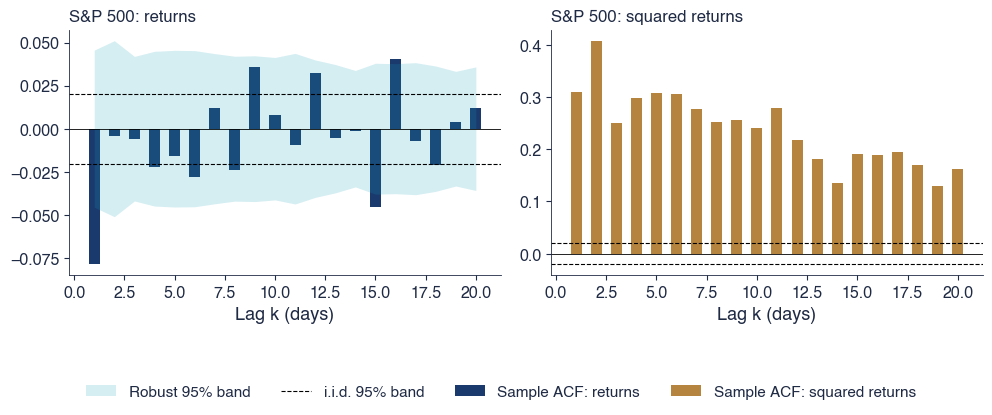

rho returns: [-0.079 -0.004 -0.006 -0.022 -0.016] | rho squared: [0.311 0.408 0.25  0.298 0.308]


,lb,p_lb,rob,p_rob
ret,90.7534,0.0,18.8138,0.0427
sq,8014.6894,0.0,189.4146,0.0000


In [14]:
# Solution
def b1_acf(k='sp500', lags=20, save=True):
    """ACF of the returns and of the squared returns with the i.i.d. and the robust 95% bands; Ljung-Box and robust
    portmanteau statistics (m = 10) for both."""
    x = returns(k).values
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    kk = np.arange(1, lags + 1)
    for ax, (lab, y, col) in zip(axes, [('Returns', x, COLORS[k]), ('Squared returns', x ** 2, st.Amber)]):
        r = acf(y, lags)
        b = 1.96 / np.sqrt(len(y))
        ax.bar(kk, r, color=col, width=0.55, label=f'Sample ACF: {lab.lower()}')
        if lab == 'Returns':
            rb = 1.96 * np.sqrt(robust_var_acf(y, lags))
            ax.fill_between(kk, -rb, rb, color=st.Teal, alpha=0.18, lw=0, label='Robust 95% band')
        ax.axhline(b, color='black', ls='--', lw=0.8, label='i.i.d. 95% band' if lab == 'Returns' else None)
        ax.axhline(-b, color='black', ls='--', lw=0.8)
        ax.axhline(0, color='black', lw=0.6)
        ax.set_title(f'{NAME[k]}: {lab.lower()}', loc='left', fontsize=12)
        ax.set_xlabel('Lag k (days)')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch7_sem_b1')
    else:
        plt.show()
    return {'ret': portmanteau(x), 'sq': portmanteau(x ** 2), 'rho': [float(v) for v in acf(x, 5)],
            'rho_sq': [float(v) for v in acf(x ** 2, 5)], 'n': len(x), 'first': returns(k).index[0].date().isoformat()}


b1 = b1_acf('sp500', save=False)
print('rho returns:', np.round(b1['rho'], 3), '| rho squared:', np.round(b1['rho_sq'], 3))
pd.DataFrame({lab: {c: b1[lab][c] for c in ['lb', 'p_lb', 'rob', 'p_rob']} for lab in ['ret', 'sq']}).T.round(4)

**Interpretation of the result.** Squared returns reject RW1 (volatility clustering); the robust test rejects RW3 only barely, because of a small negative first autocorrelation.

## B2 [Proposed]: BET, Bitcoin and two BVB stocks

**Question.** For which of the BET, Bitcoin, Banca Transilvania and OMV Petrom does the verdict on autocorrelation change between the classic and the robust test? Model: B1.

1. Compute $\hat\rho(1)$, $Q_{LB}(10)$ and $\tilde Q(10)$ with p-values for each series.
2. Compute the runs test $z$ and its p-value for each series.
3. Mark the series for which the classic and the robust test disagree at 5%.
4. Interpretation: why is the BET different from the other three?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: unit roots in the DAX

**Question.** What is the order of integration of the DAX log price and of its returns?

1. Draw the log price with a fitted linear trend, and the returns.
2. Run ADF (lag order by AIC), PP and KPSS on the log price with a constant and a trend.
3. Run the same three tests on the returns with a constant.
4. Interpretation: does a unit root in the DAX price prove that the DAX is weak-form efficient?

**Report:** the chart, six statistics with p-values and two sentences.

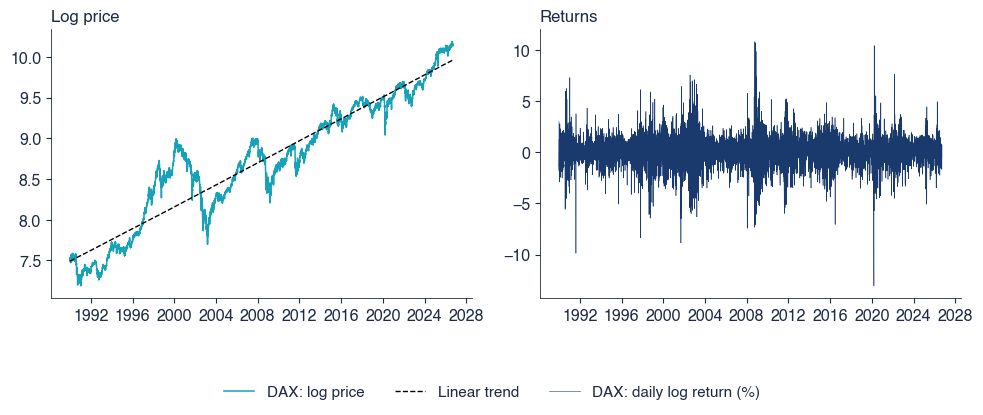

stat      p  lags    nobs  crit5
price adf   -2.693  0.239  30.0  9258.0 -3.411
      pp    -2.645  0.260  38.0     NaN -3.411
      kpss   0.938  0.010  38.0     NaN  0.146
ret   adf  -23.302  0.000  17.0  9270.0 -2.862
      pp   -97.398  0.000  38.0     NaN -2.862
      kpss   0.043  0.100  38.0     NaN  0.463

In [16]:
# Solution
def b3_unit_root(k='dax', save=True):
    """ADF, Phillips-Perron and KPSS on the log price (constant and trend) and on the returns (constant), with a
    chart of both series."""
    lp, r = log_price(k), returns(k)
    res = {'price': {'adf': adf_test(lp.values, 'ct'), 'pp': pp_test(lp.values, 'ct'), 'kpss': kpss_test(lp.values, 'ct')},
           'ret': {'adf': adf_test(r.values, 'c'), 'pp': pp_test(r.values, 'c'), 'kpss': kpss_test(r.values, 'c')},
           'n': len(r), 'first': r.index[0].date().isoformat()}
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    t = np.arange(len(lp))
    b = np.polyfit(t, lp.values, 1)
    axes[0].plot(lp.index, lp.values, color=COLORS[k], lw=1.1, label=f'{NAME[k]}: log price')
    axes[0].plot(lp.index, b[1] + b[0] * t, color='black', lw=1, ls='--', label='Linear trend')
    axes[1].plot(r.index, r.values, color=st.MainBlue, lw=0.4, label=f'{NAME[k]}: daily log return (%)')
    axes[0].set_title('Log price', loc='left', fontsize=12)
    axes[1].set_title('Returns', loc='left', fontsize=12)
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch7_sem_b3')
    else:
        plt.show()
    return res


b3 = b3_unit_root('dax', save=False)
pd.DataFrame({(s_, t): b3[s_][t] for s_ in ['price', 'ret'] for t in ['adf', 'pp', 'kpss']}).T.round(3)

**Interpretation of the result.** The log price is $I(1)$ and the returns are $I(0)$; a unit root is necessary for a random walk but does not prove efficiency: that is tested on the returns (B1, B5).

## B4 [Proposed]: BET, Bitcoin and TLV

**Question.** Do the three unit-root tests agree for the BET, Bitcoin and Banca Transilvania? Model: B3.

1. Run ADF, PP and KPSS on each log price (constant and trend) and on each return series (constant).
2. Classify each series as $I(1)$, $I(0)$ or inconclusive.
3. For an inconclusive case, propose one check that could settle it.
4. Interpretation: would you trade a "mean-reverting" TLV price on this evidence?

**Report:** one table, three classifications and two sentences.

In [ ]:
# Your code here


## B5 [Solved]: variance ratios of the S&P 500

**Question.** Is the S&P 500 mean-reverting over horizons of 2 to 20 days, once volatility clustering is taken into account?

1. Compute VR($q$), $Z(q)$ and $Z^*(q)$ for $q = 2, 5, 10, 20$.
2. Compute the Chow–Denning statistic and compare it with its 5% critical value.
3. Draw VR($q$) for $q = 2, \dots, 40$ with the i.i.d. and the robust 95% bands.
4. Interpretation: is the mean reversion large enough to matter for an investor?

**Report:** a table of twelve numbers, one statistic, the chart and two sentences.

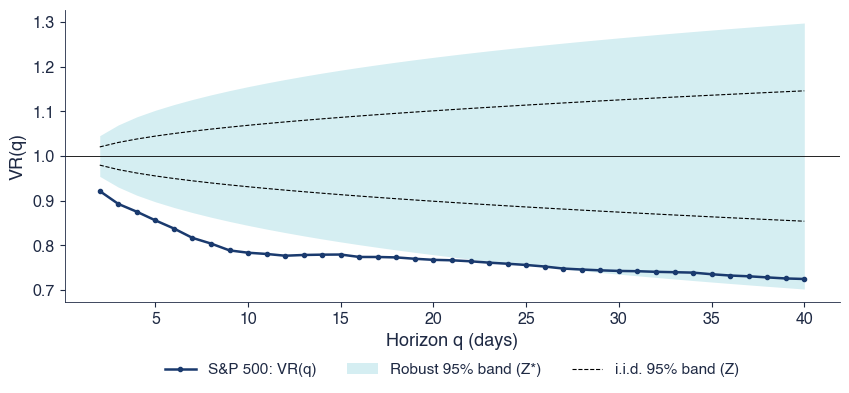

{'cd': 3.374636057358931, 'p': 0.002953258459202912, 'crit': 2.4909151310191393, 'm': 4}


,2,5,10,20
vr,0.922,0.856,0.783,0.767
z,-7.545,-6.329,-6.171,-4.500
zs,-3.375,-2.756,-2.732,-2.062
p_zs,0.001,0.006,0.006,0.039


In [18]:
# Solution
def b5_vr(k='sp500', qmax=40, save=True):
    """VR(q), Z(q), Z*(q) for q = 2, 5, 10, 20; the Chow-Denning test; the VR profile with both bands."""
    x = returns(k).values
    res = {'vr': {q: variance_ratio(x, q) for q in QS}, 'cd': chow_denning(x), 'n': len(x), 'rho1': float(acf(x, 1)[0]),
           'first': returns(k).index[0].date().isoformat()}
    qs, vr, se, se0 = vr_profile(x, qmax)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(qs, vr, color=COLORS[k], lw=1.8, marker='o', ms=3, label=f'{NAME[k]}: VR(q)')
    ax.fill_between(qs, 1 - 1.96 * se, 1 + 1.96 * se, color=st.Teal, alpha=0.18, lw=0, label='Robust 95% band (Z*)')
    ax.plot(qs, 1 + 1.96 * se0, color='black', ls='--', lw=0.8, label='i.i.d. 95% band (Z)')
    ax.plot(qs, 1 - 1.96 * se0, color='black', ls='--', lw=0.8)
    ax.axhline(1, color='black', lw=0.6)
    ax.set_xlabel('Horizon q (days)')
    ax.set_ylabel('VR(q)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch7_sem_b5')
    else:
        plt.show()
    return res


b5 = b5_vr('sp500', save=False)
print(b5['cd'])
pd.DataFrame(b5['vr']).loc[['vr', 'z', 'zs', 'p_zs']].round(3)

**Interpretation of the result.** Significant at every horizon with the robust test, but small: VR(5) is only modestly below 1, and $Z$ exaggerates the evidence compared with $Z^*$.

## B6 [Proposed]: five emerging markets

**Question.** Which of the WIG20, BUX, PX, BET and BIST 100 departs from a random walk over the last ten years? Model: B5.

1. Compute VR(5), $Z^*(5)$ and its p-value for each market.
2. Compute the Chow–Denning p-value ($q = 2, 5, 10, 20$) and the automatic VR test with its wild-bootstrap p-value.
3. Compute the Šidák critical value for five markets tested together at 5%.
4. Interpretation: which markets would you call inefficient once you account for testing five markets?

**Report:** one table, one critical value and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: has the BET become more efficient?

**Question.** How has the predictability of the BET evolved since 1997, including around the FTSE Russell upgrade of September 2020? Models: B1, B5.

1. Compute VR(5) and $Z^*(5)$ on rolling windows of 500 days, one every 21 days, and the share of windows with $|Z^*(5)| > 1.96$ in the first and in the last five years.
2. Compute $\hat\rho(1)$, VR(5), $Z^*(5)$ and the Chow–Denning p-value in 1997–2006, 2007–2016 and 2017–2026.
3. Compare VR(5) in the five years before and after 21 September 2020.
4. List what else changed in the Romanian market at the same time.
5. Interpretation: how would you separate these changes from the effect of the upgrade?

**Report:** a table, one chart and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant was asked whether the DAX (daily, since 1990) is weak-form efficient. It answered:

- (a) ADF on the DAX log price does not reject a unit root, so the DAX is weak-form efficient;
- (b) Ljung–Box $Q(10)$ has a p-value below 5%, so DAX returns are predictable and the DAX is not efficient;
- (c) the Ljung–Box statistic of the squared returns is huge, so DAX returns are not a martingale;
- (d) VR(10) < 1 shows positive autocorrelation (momentum) in the DAX;
- (e) under RW1, VR(q) = 1 at every horizon and the variance of q-day returns is q times the daily variance.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** five verdicts with one line of justification each.

In [ ]:
# Your code here
